In [1]:
# =========================================================
# 0. LIBRERÍAS
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import radians, sin, cos, atan2, sqrt
from IPython.display import display

In [2]:
# =========================================================
# 1. RUTAS Y PARÁMETROS
# =========================================================

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

# Rutas de los CSV (ya confirmadas)
RUTA_12 = "/content/drive/MyDrive/Inv-Acc/12ago.csv"
RUTA_04 = "/content/drive/MyDrive/Inv-Acc/04ago.csv"

# Punto oficial de impacto (Yerbabueña – Chía)
IMPACT_LAT = 4.859028      # N04°51'32.5"
IMPACT_LON = -74.006778    # W74°00'24.4"
IMPACT_ALT_FT = 9542.0

# Punto aproximado de configuración FULL FLAPS (según 4-ago)
# N4° 51' 52.7"  W74° 00' 59.0"
FULL_FLAPS_LAT = 4 + 51/60 + 52.7/3600     # ≈ 4.864639
FULL_FLAPS_LON = -(74 + 0/60 + 59.0/3600) # ≈ -74.016389

# Peso aproximado
WEIGHT_LB = 5000.0

In [3]:
 =========================================================
# 2. FUNCIONES GEOGRÁFICAS
# =========================================================

def haversine(lat1, lon1, lat2, lon2):
    """
    Distancia entre dos puntos en la Tierra (m).
    """
    R = 6371000.0  # m
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi/2)**2 + cos(phi1)*cos(phi2)*sin(dlambda/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

def initial_bearing(lat1, lon1, lat2, lon2):
    """
    Rumbo inicial verdadero de un punto a otro (grados 0–360).
    """
    phi1, phi2 = radians(lat1), radians(lat2)
    dlambda = radians(lon2 - lon1)
    x = sin(dlambda) * cos(phi2)
    y = cos(phi1)*sin(phi2) - sin(phi1)*cos(phi2)*cos(dlambda)
    theta = atan2(x, y)
    brg = (np.degrees(theta) + 360) % 360
    return brg

In [4]:
# =========================================================
# 3. CARGA DE CSV Y PREPROCESAMIENTO
# =========================================================

def cargar_traza(path):
    """
    Lee CSV con columnas:
    lat_deg,lon_deg,alt_ft,vel_kt,t_s,heading_deg
    y fuerza tipos numéricos.
    """
    df = pd.read_csv(path)

    for col in ["lat_deg", "lon_deg", "alt_ft", "vel_kt", "t_s", "heading_deg"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Ordenar por tiempo por seguridad
    df = df.sort_values("t_s").reset_index(drop=True)

    return df

print("Cargando datos de 12-ago y 04-ago…\n")
df12 = cargar_traza(RUTA_12)
df04 = cargar_traza(RUTA_04)

print("Puntos 12-ago:", len(df12))
print("Puntos 04-ago:", len(df04))

print("\nMuestra 12-ago:")
display(df12.head())

Cargando datos de 12-ago y 04-ago…

Puntos 12-ago: 23
Puntos 04-ago: 38

Muestra 12-ago:


,lat_deg,lon_deg,alt_ft,vel_kt,t_s,heading_deg
0,4.814305,-74.072528,8455,0.2,0,108.0
1,4.814305,-74.072500,8451,11.0,28,103.0
2,4.814222,-74.071056,8451,30.0,35,102.0
3,4.814056,-74.071333,8448,46.0,41,103.0
4,4.813722,-74.069889,8447,60.0,48,103.0


In [6]:
# =========================================================
# 4. CÁLCULO CINEMÁTICO
# =========================================================

def compute_kinematics(df):
    """
    A partir de lat/lon/alt/t/vel calcula:
      - dist_seg_m, dist_tot_m, dist_tot_nm
      - track_deg
      - Vg_mps, Vg_kt
      - Vv_fpm
      - gamma_deg (ángulo de trayectoria)
      - turn_rate_dps
      - bank_deg (banco estimado)
    """
    df = df.copy()

    # -----------------------------
    # Distancias y rumbos
    # -----------------------------
    dist_seg = [0.0]
    track = [np.nan]

    for i in range(1, len(df)):
        lat1, lon1 = df.lat_deg.iloc[i-1], df.lon_deg.iloc[i-1]
        lat2, lon2 = df.lat_deg.iloc[i],   df.lon_deg.iloc[i]

        d = haversine(lat1, lon1, lat2, lon2)
        dist_seg.append(d)

        brg = initial_bearing(lat1, lon1, lat2, lon2)
        track.append(brg)

    df["dist_seg_m"]  = dist_seg
    df["dist_tot_m"]  = df["dist_seg_m"].cumsum()
    df["dist_tot_nm"] = df["dist_tot_m"] / 1852.0
    df["track_deg"]   = track

    # -----------------------------
    # Δ tiempo
    # -----------------------------
    df["dt_s"] = df["t_s"].diff()
    df.loc[df["dt_s"] <= 0, "dt_s"] = np.nan

    # -----------------------------
    # Velocidad en el suelo
    # -----------------------------
    df["Vg_kt"]  = df["vel_kt"]
    df["Vg_mps"] = df["Vg_kt"] * 0.514444

    # -----------------------------
    # Velocidad vertical
    # -----------------------------
    df["dalt_ft"] = df["alt_ft"].diff()
    df["Vv_fpm"]  = df["dalt_ft"] / df["dt_s"] * 60.0

    # -----------------------------
    # Ángulo de trayectoria γ
    # -----------------------------
    Vv_fts = df["Vv_fpm"] / 60.0
    Vg_fts = df["Vg_mps"] * 3.28084
    df["gamma_deg"] = np.degrees(np.arctan(Vv_fts / Vg_fts))

    # -----------------------------
    # Razón de viraje
    # -----------------------------
    dtrk = df["track_deg"].diff()
    dtrk = ((dtrk + 180.0) % 360.0) - 180.0
    df["turn_rate_dps"] = dtrk / df["dt_s"]

    # -----------------------------
    # Banqueo estimado (viraje coordinado)
    # -----------------------------
    g = 9.80665
    omega = np.radians(df["turn_rate_dps"])
    df["bank_deg"] = np.degrees(np.arctan(df["Vg_mps"] * omega / g))

    return df

df12k = compute_kinematics(df12)
df04k = compute_kinematics(df04)

print("Columnas cinemáticas 12-ago:")
print(df12k.columns)

Columnas cinemáticas 12-ago:
Index(['lat_deg', 'lon_deg', 'alt_ft', 'vel_kt', 't_s', 'heading_deg',
       'dist_seg_m', 'dist_tot_m', 'dist_tot_nm', 'track_deg', 'dt_s', 'Vg_kt',
       'Vg_mps', 'dalt_ft', 'Vv_fpm', 'gamma_deg', 'turn_rate_dps',
       'bank_deg'],
      dtype='object')


In [7]:
# =========================================================
# 5. PERFORMANCE BN-2B (STALL FULL FLAPS)
# =========================================================

def stall_speed_full_flaps(weight_lb=5000.0, Vs0_4000=47.0):
    """
    Estima Vs full flaps al peso dado,
    asumiendo Vs0 ~ 47 kt a 4000 lb.
    """
    return Vs0_4000 * np.sqrt(weight_lb / 4000.0)

VS_full = stall_speed_full_flaps(WEIGHT_LB)
print(f"Vs estimada full flaps (W={WEIGHT_LB:.0f} lb): {VS_full:.1f} kt")

Vs estimada full flaps (W=5000 lb): 52.5 kt


In [8]:
# =========================================================
# 6. PROYECCIÓN CURVA DEL 12-AGO + RECORTE DEL 4-AGO
# =========================================================

R_EARTH = 6371000.0  # radio medio de la Tierra (m)

# ---------------------------------------------------------
# Conversión lat/lon <-> coordenadas locales x,y
# ---------------------------------------------------------

def ll_to_xy(lat_deg, lon_deg, lat0_deg, lon0_deg):
    """
    Convierte lat/lon a coordenadas locales x,y (m)
    tomando como origen (lat0, lon0).
    """
    lat = np.radians(lat_deg)
    lon = np.radians(lon_deg)
    lat0 = np.radians(lat0_deg)
    lon0 = np.radians(lon0_deg)

    x = (lon - lon0) * np.cos(lat0) * R_EARTH
    y = (lat - lat0) * R_EARTH
    return x, y


def xy_to_ll(x, y, lat0_deg, lon0_deg):
    """
    Convierte x,y locales (m) a lat/lon (deg) tomando como origen (lat0, lon0).
    """
    lat0 = np.radians(lat0_deg)
    lon0 = np.radians(lon0_deg)

    lat = lat0 + y / R_EARTH
    lon = lon0 + x / (R_EARTH * np.cos(lat0))

    return np.degrees(lat), np.degrees(lon)

# ---------------------------------------------------------
# Recorte del 4-ago hasta cruce lateral con punto de impacto
# ---------------------------------------------------------

def recortar_4ago_en_impacto(df04k):
    """
    Recorta el 4-ago hasta el punto más cercano al impacto real.
    """
    dist_imp = df04k.apply(
        lambda r: haversine(r.lat_deg, r.lon_deg, IMPACT_LAT, IMPACT_LON),
        axis=1
    )
    idx = dist_imp.idxmin()
    df_trim = df04k.iloc[:idx+1].reset_index(drop=True)
    return df_trim, idx

# ---------------------------------------------------------
# Punto de FULL FLAPS (aprox.)
# ---------------------------------------------------------

def encontrar_full_flaps(df, lat_ref, lon_ref):
    """
    Retorna el índice del punto del 4-ago más cercano
    al punto en que se estima FULL FLAPS.
    """
    dist_ff = df.apply(
        lambda r: haversine(r.lat_deg, r.lon_deg, lat_ref, lon_ref),
        axis=1
    )
    idx_ff = dist_ff.idxmin()
    return (
        idx_ff,
        df.t_s.iloc[idx_ff],
        df.dist_tot_nm.iloc[idx_ff],
        df.alt_ft.iloc[idx_ff]
    )

# ---------------------------------------------------------
# PROYECCIÓN CURVA del 12-ago basada en geometría del 4-ago
# ---------------------------------------------------------

def proyectar_12_hasta_impacto_curvo(df12k, df04k):
    """
    Proyecta la trayectoria faltante del 12-ago usando la FORMA en curva
    del tramo equivalente del 4-ago (no una recta).
    """

    # Último punto real del 12-ago
    latL = df12k.lat_deg.iloc[-1]
    lonL = df12k.lon_deg.iloc[-1]
    altL = df12k.alt_ft.iloc[-1]
    tL   = df12k.t_s.iloc[-1]
    VL   = df12k.vel_kt.iloc[-1]

    # Distancia recta (informativa)
    dist_faltante_m = haversine(latL, lonL, IMPACT_LAT, IMPACT_LON)

    # Buscar punto del 4-ago más cercano al último punto del 12-ago
    dL = df04k.apply(lambda r: haversine(r.lat_deg, r.lon_deg, latL, lonL), axis=1)
    idx0 = dL.idxmin()

    # Buscar punto del 4-ago más cercano al impacto
    dI = df04k.apply(lambda r: haversine(r.lat_deg, r.lon_deg, IMPACT_LAT, IMPACT_LON), axis=1)
    idx1 = dI.idxmin()

    if idx1 <= idx0:
        idx0, idx1 = sorted([idx0, idx1])

    seg04 = df04k.iloc[idx0:idx1+1].reset_index(drop=True)

    # Convertir el segmento 04-ago a coordenadas locales x,y
    lat_ref0 = seg04.lat_deg.iloc[0]
    lon_ref0 = seg04.lon_deg.iloc[0]

    x_ref, y_ref = ll_to_xy(seg04.lat_deg.values,
                            seg04.lon_deg.values,
                            lat_ref0, lon_ref0)

    # Vector final del segmento
    x_end_ref = x_ref[-1]
    y_end_ref = y_ref[-1]

    # Vector requerido 12-ago -> impacto en x,y
    v_imp_x, v_imp_y = ll_to_xy(IMPACT_LAT, IMPACT_LON, latL, lonL)

    len_ref = np.hypot(x_end_ref, y_end_ref)
    len_imp = np.hypot(v_imp_x, v_imp_y)

    scale = len_imp / max(len_ref, 1e-6)

    ang_ref = np.arctan2(y_end_ref, x_end_ref)
    ang_imp = np.arctan2(v_imp_y,  v_imp_x)
    dtheta = ang_imp - ang_ref

    # Aplicar rotación + escala
    x_rot = x_ref * np.cos(dtheta) - y_ref * np.sin(dtheta)
    y_rot = x_ref * np.sin(dtheta) + y_ref * np.cos(dtheta)

    x_proj = x_rot * scale
    y_proj = y_rot * scale

    # Desplazar el origen al último punto 12-ago
    lat_proj, lon_proj = xy_to_ll(x_proj, y_proj, latL, lonL)

    # Longitud del arco para tiempo de impacto
    dx = np.diff(x_proj)
    dy = np.diff(y_proj)
    arco_m = np.sum(np.hypot(dx, dy))

    # Velocidad promedio entre V_last y velocidad ref final
    V_ref_end = seg04.vel_kt.iloc[-1]
    V_mean_kt = (VL + V_ref_end) / 2
    V_mean_mps = max(V_mean_kt * 0.514444, 5.0)

    dt_total = arco_m / V_mean_mps
    t_impacto = tL + dt_total

    # Generar vector de tiempos interpolado
    N = len(seg04) - 1
    ts_proj = np.linspace(tL, t_impacto, N+1)[1:]

    # Altitud descendiendo linealmente a altitud de impacto
    alt_proj = np.linspace(altL, IMPACT_ALT_FT, N+1)[1:]

    # Velocidad interpolada
    vel_proj = np.linspace(VL, V_ref_end, N+1)[1:]

    df_extra = pd.DataFrame({
        "lat_deg":     lat_proj[1:],
        "lon_deg":     lon_proj[1:],
        "alt_ft":      alt_proj,
        "vel_kt":      vel_proj,
        "t_s":         ts_proj,
        "heading_deg": np.nan
    })

    # Combinar tramo real + proyectado curvo
    df12_ext_raw = pd.concat([
        df12k[["lat_deg","lon_deg","alt_ft","vel_kt","t_s","heading_deg"]],
        df_extra
    ], ignore_index=True)

    df12_ext = compute_kinematics(df12_ext_raw)

    return df12_ext, t_impacto, dt_total, dist_faltante_m

# ---------------------------------------------------------
# EJECUCIÓN DE ESTA SECCIÓN
# ---------------------------------------------------------

print("===== EXTENSIÓN CURVA DEL 12-AGO HASTA EL IMPACTO =====")

df12_ext, t_impacto, dt_faltante, dist_faltante_m = proyectar_12_hasta_impacto_curvo(df12k, df04k)

print(f"Tiempo último punto (12-ago): {df12k.t_s.iloc[-1]:.1f} s")
print(f"Tiempo estimado de impacto:   {t_impacto:.1f} s")
print(f"Δt faltante (arco curvo):     {dt_faltante:.1f} s")
print(f"Distancia faltante recta:     {dist_faltante_m/1852.0:.2f} NM\n")

# Recortar el 4-ago hasta cruce lateral con impacto
df04_trim, idx_imp04 = recortar_4ago_en_impacto(df04k)

# Punto full flaps
idx_ff, t_ff, d_ff_nm, alt_ff = encontrar_full_flaps(df04_trim,
                                                     FULL_FLAPS_LAT,
                                                     FULL_FLAPS_LON)

print("===== UBICACIÓN ESTIMADA DE FULL FLAPS (4-AGO) =====")
print(f"Índice: {idx_ff}")
print(f"Tiempo desde inicio: {t_ff:.1f} s")
print(f"Distancia: {d_ff_nm:.2f} NM")
print(f"Altitud: {alt_ff:.1f} ft\n")

===== EXTENSIÓN CURVA DEL 12-AGO HASTA EL IMPACTO =====
Tiempo último punto (12-ago): 206.0 s
Tiempo estimado de impacto:   nan s
Δt faltante (arco curvo):     nan s
Distancia faltante recta:     1.72 NM

===== UBICACIÓN ESTIMADA DE FULL FLAPS (4-AGO) =====
Índice: 33
Tiempo desde inicio: 277.0 s
Distancia: 5.15 NM
Altitud: 9663.0 ft



In [9]:
# =========================================================
# 6. COORDENADAS LOCALES CONSISTENTES (ENU)
# =========================================================
import numpy as np

R = 6371000  # radio terrestre en metros

def latlon_to_xy(lat, lon, lat0, lon0):
    """
    Convierte lat/lon a coordenadas locales X,Y con origen en lat0,lon0.
    X = hacia el ESTE
    Y = hacia el NORTE
    """
    lat  = np.radians(lat)
    lon  = np.radians(lon)
    lat0 = np.radians(lat0)
    lon0 = np.radians(lon0)

    x = (lon - lon0) * np.cos(lat0) * R
    y = (lat - lat0) * R
    return x, y

# ORIGEN: Cabecera pista 11 SKGY (primer punto del dataset)
lat0 = df12_ext.lat_deg.iloc[0]
lon0 = df12_ext.lon_deg.iloc[0]

# Coordenadas locales para 12-ago extendido
x12, y12 = latlon_to_xy(df12_ext.lat_deg.values,
                        df12_ext.lon_deg.values,
                        lat0, lon0)

df12_ext["x_local"] = x12
df12_ext["y_local"] = y12

# Coordenadas locales para 4-ago recortado
x04, y04 = latlon_to_xy(df04_trim.lat_deg.values,
                        df04_trim.lon_deg.values,
                        lat0, lon0)

df04_trim["x_local"] = x04
df04_trim["y_local"] = y04

# Coordenadas del impacto en el mismo sistema
Ximp, Yimp = latlon_to_xy(IMPACT_LAT, IMPACT_LON, lat0, lon0)
print("Impacto en coords locales: ", Ximp, Yimp)

Impacto en coords locales:  7285.272519535123 4972.9707043246035


Generando gráficas comparativas vs tiempo…


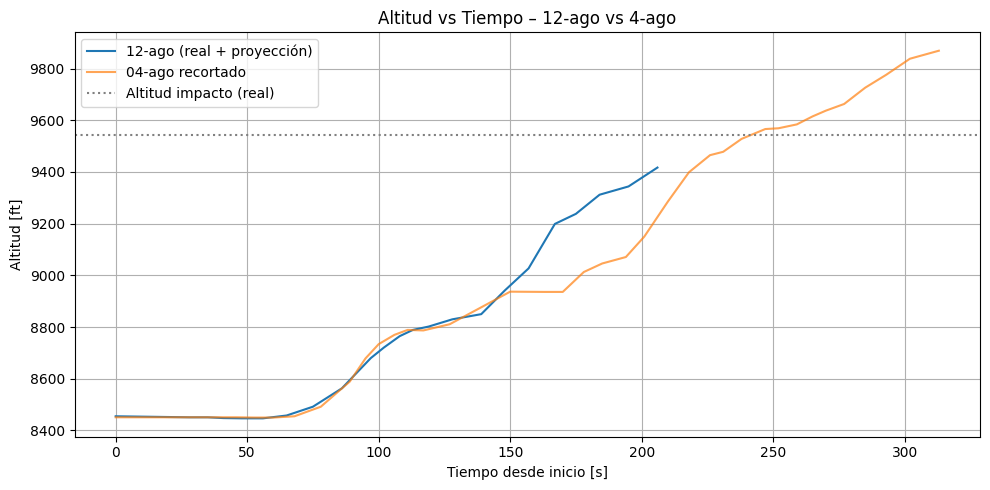

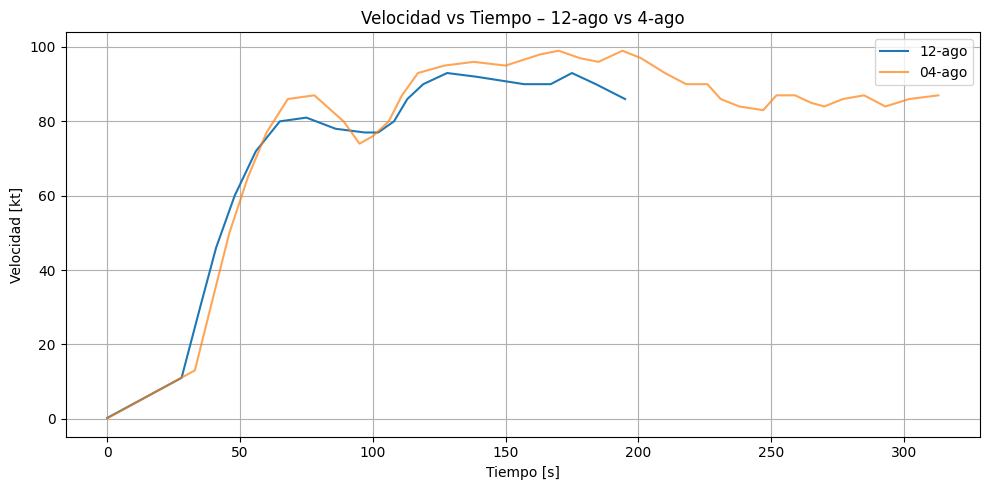

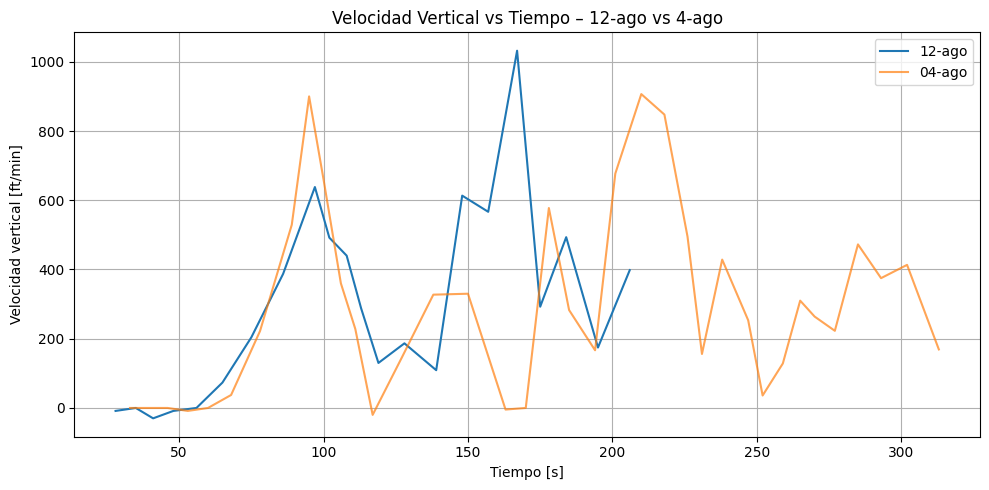

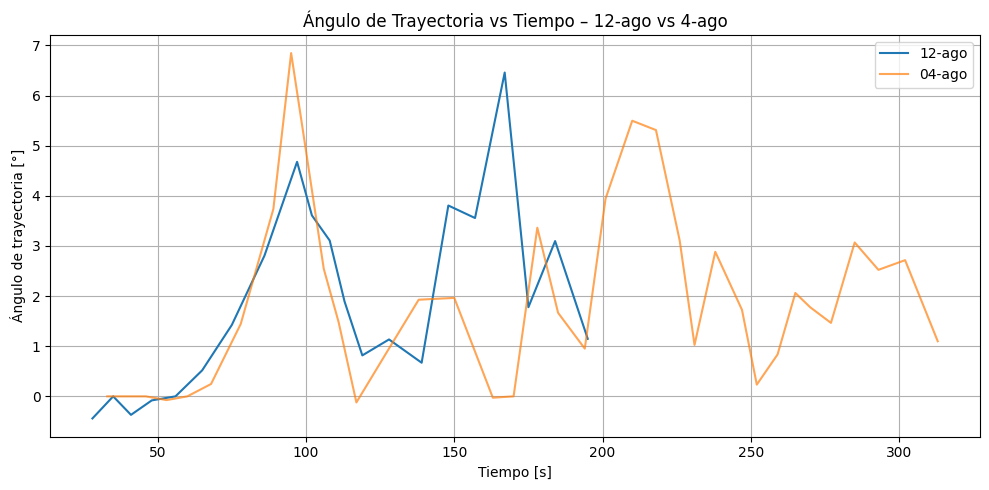

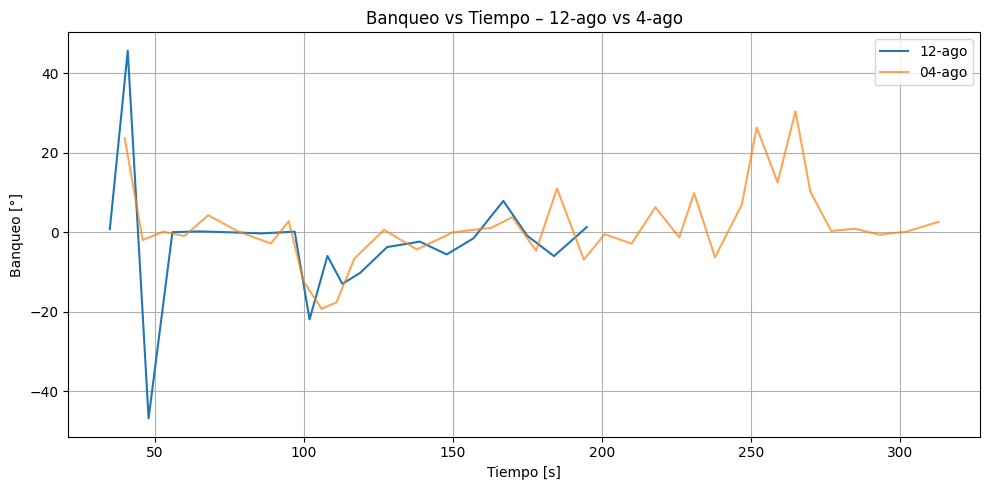

Generando gráficas comparativas vs distancia…


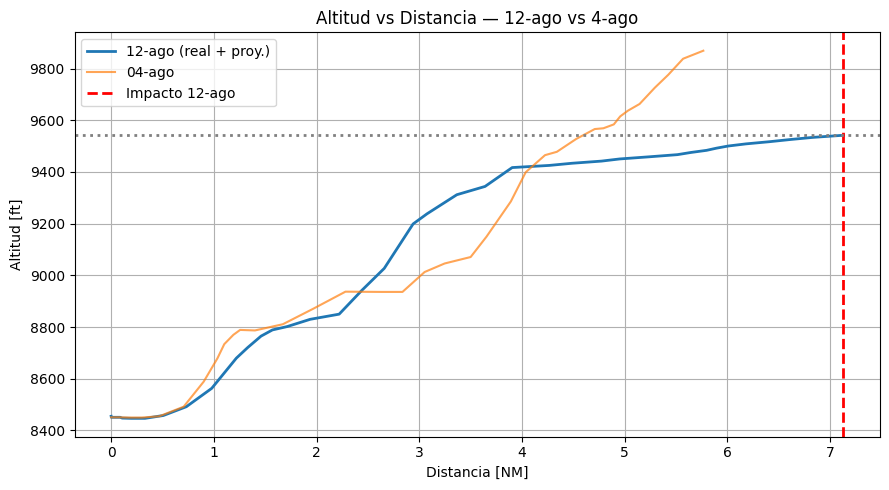

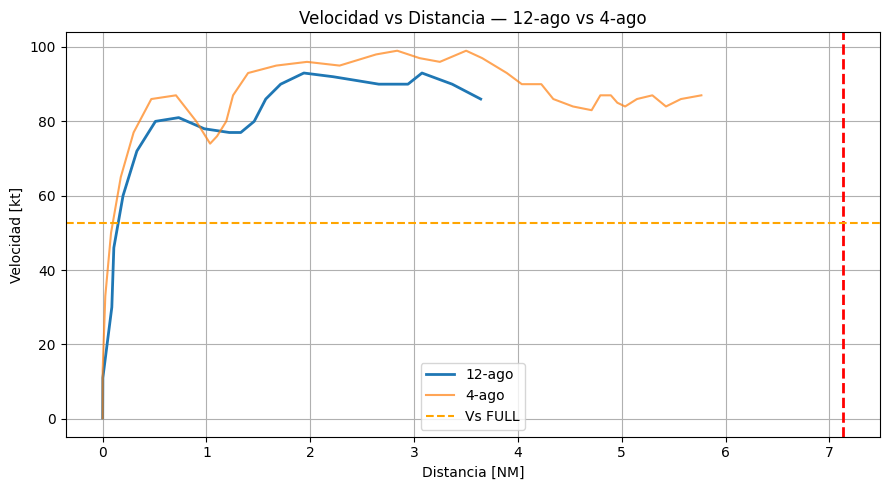

Generando trayectoria en planta…


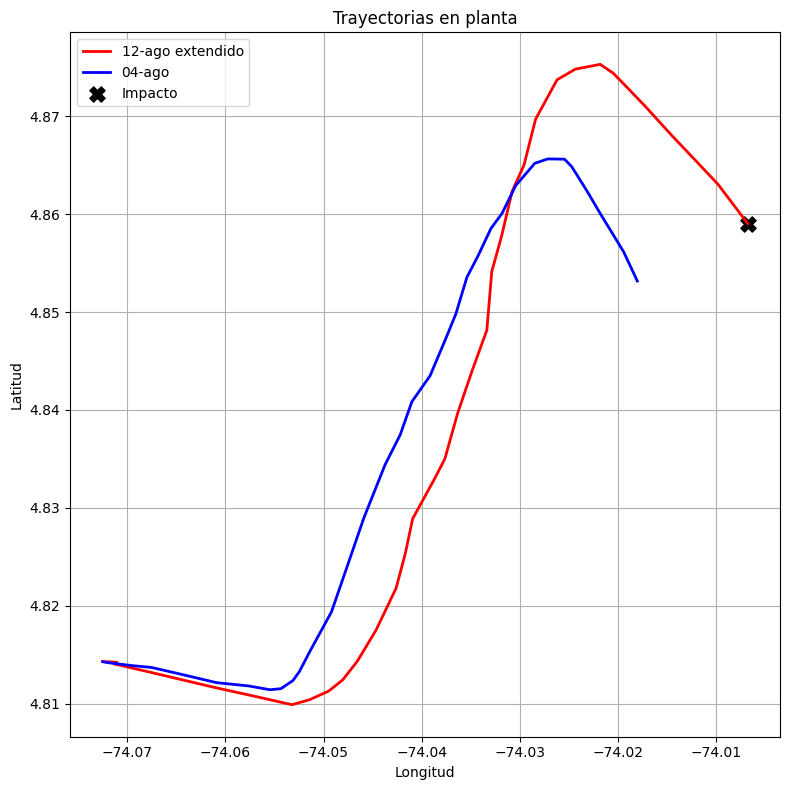

In [10]:
# =========================================================
# 7.1 GRÁFICAS COMPARATIVAS VS TIEMPO (con línea roja de impacto)
# =========================================================

def plot_comparativo_tiempo(df12_ext, df04_trim, t_impacto):
    """
    Gráficas vs tiempo de:
      - Altitud
      - Velocidad
      - Velocidad vertical
      - Ángulo de trayectoria γ
      - Banqueo

    Cada gráfica incluye:
      ✔ 12-ago (real + proyección)
      ✔ 4-ago (recortado)
      ✔ Línea vertical roja EXACTA en t_impacto
      ✔ Etiqueta de tiempo de impacto
    """

    t12 = df12_ext["t_s"]
    t04 = df04_trim["t_s"]

    # ================= ALTITUD =================
    plt.figure(figsize=(10, 5))
    plt.plot(t12, df12_ext["alt_ft"], label="12-ago (real + proyección)")
    plt.plot(t04, df04_trim["alt_ft"], label="04-ago recortado", alpha=0.7)

    # Línea del impacto
    plt.axvline(t_impacto, color="red", linestyle="--", linewidth=2)
    plt.text(t_impacto, df12_ext["alt_ft"].max()*0.95,
             f"Impacto\n{t_impacto:.1f}s",
             color="red", ha="left", va="top")

    plt.axhline(IMPACT_ALT_FT, color="grey", linestyle=":", label="Altitud impacto (real)")

    plt.xlabel("Tiempo desde inicio [s]")
    plt.ylabel("Altitud [ft]")
    plt.title("Altitud vs Tiempo – 12-ago vs 4-ago")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ================= VELOCIDAD =================
    plt.figure(figsize=(10, 5))
    plt.plot(t12, df12_ext["Vg_kt"], label="12-ago")
    plt.plot(t04, df04_trim["Vg_kt"], label="04-ago", alpha=0.7)

    plt.axvline(t_impacto, color="red", linestyle="--", linewidth=2)
    plt.text(t_impacto, df12_ext["Vg_kt"].max()*0.95,
             f"Impacto\n{t_impacto:.1f}s",
             color="red", ha="left", va="top")

    plt.xlabel("Tiempo [s]")
    plt.ylabel("Velocidad [kt]")
    plt.title("Velocidad vs Tiempo – 12-ago vs 4-ago")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ================= VELOCIDAD VERTICAL =================
    plt.figure(figsize=(10, 5))
    plt.plot(t12, df12_ext["Vv_fpm"], label="12-ago")
    plt.plot(t04, df04_trim["Vv_fpm"], label="04-ago", alpha=0.7)

    plt.axvline(t_impacto, color="red", linestyle="--", linewidth=2)
    plt.text(t_impacto, df12_ext["Vv_fpm"].max()*0.95,
             f"Impacto\n{t_impacto:.1f}s",
             color="red", ha="left", va="top")

    plt.xlabel("Tiempo [s]")
    plt.ylabel("Velocidad vertical [ft/min]")
    plt.title("Velocidad Vertical vs Tiempo – 12-ago vs 4-ago")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ================= ÁNGULO DE TRAYECTORIA =================
    plt.figure(figsize=(10, 5))
    plt.plot(t12, df12_ext["gamma_deg"], label="12-ago")
    plt.plot(t04, df04_trim["gamma_deg"], label="04-ago", alpha=0.7)

    plt.axvline(t_impacto, color="red", linestyle="--", linewidth=2)
    plt.text(t_impacto, df12_ext["gamma_deg"].max()*0.95,
             f"Impacto\n{t_impacto:.1f}s",
             color="red", ha="left", va="top")

    plt.xlabel("Tiempo [s]")
    plt.ylabel("Ángulo de trayectoria [°]")
    plt.title("Ángulo de Trayectoria vs Tiempo – 12-ago vs 4-ago")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ================= BANQUEO =================
    plt.figure(figsize=(10, 5))
    plt.plot(t12, df12_ext["bank_deg"], label="12-ago")
    plt.plot(t04, df04_trim["bank_deg"], label="04-ago", alpha=0.7)

    plt.axvline(t_impacto, color="red", linestyle="--", linewidth=2)
    plt.text(t_impacto, df12_ext["bank_deg"].max()*0.95,
             f"Impacto\n{t_impacto:.1f}s",
             color="red", ha="left", va="top")

    plt.xlabel("Tiempo [s]")
    plt.ylabel("Banqueo [°]")
    plt.title("Banqueo vs Tiempo – 12-ago vs 4-ago")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# =========================================================
# COMPARATIVOS vs DISTANCIA
# =========================================================

def plot_comparativo_distancia(df12_ext, df04_trim):

    d12 = df12_ext["dist_tot_nm"]
    d04 = df04_trim["dist_tot_nm"]

    d_impact = d12.iloc[-1]

    # =============== ALTITUD ===============
    plt.figure()
    plt.plot(d12, df12_ext["alt_ft"], label="12-ago (real + proy.)", linewidth=2)
    plt.plot(d04, df04_trim["alt_ft"], label="04-ago", alpha=0.7)

    plt.axvline(d_impact, color="red", linestyle="--", linewidth=2, label="Impacto 12-ago")
    plt.axhline(IMPACT_ALT_FT, color="gray", linestyle=":", linewidth=2)

    plt.xlabel("Distancia [NM]")
    plt.ylabel("Altitud [ft]")
    plt.title("Altitud vs Distancia — 12-ago vs 4-ago")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # =============== VELOCIDAD ===============
    plt.figure()
    plt.plot(d12, df12_ext["Vg_kt"], label="12-ago", linewidth=2)
    plt.plot(d04, df04_trim["Vg_kt"], label="4-ago", alpha=0.7)

    plt.axvline(d_impact, color="red", linestyle="--", linewidth=2)
    plt.axhline(VS_full, color="orange", linestyle="--", label="Vs FULL")

    plt.xlabel("Distancia [NM]")
    plt.ylabel("Velocidad [kt]")
    plt.title("Velocidad vs Distancia — 12-ago vs 4-ago")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# =========================================================
# TRAYECTORIAS EN PLANTA — USANDO LAT/LON DIRECTOS
# =========================================================

def plot_trayectorias_planta(df12_ext, df04_trim):
    plt.figure(figsize=(8, 8))

    # Coordenadas reales
    x12 = df12_ext["lon_deg"].copy()
    y12 = df12_ext["lat_deg"].copy()

    x04 = df04_trim["lon_deg"].copy()
    y04 = df04_trim["lat_deg"].copy()

    # Trayectorias
    plt.plot(x12, y12, color="red", linewidth=2, label="12-ago extendido")
    plt.plot(x04, y04, color="blue", linewidth=2, label="04-ago")

    # Punto de impacto real
    plt.scatter(IMPACT_LON, IMPACT_LAT, c="black", s=120, marker="X", label="Impacto")

    plt.xlabel("Longitud")
    plt.ylabel("Latitud")
    plt.title("Trayectorias en planta")

    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

# =========================================================
# EJECUCIÓN SECCIÓN 7
# =========================================================

print("Generando gráficas comparativas vs tiempo…")
plot_comparativo_tiempo(df12_ext, df04_trim, t_impacto)

print("Generando gráficas comparativas vs distancia…")
plot_comparativo_distancia(df12_ext, df04_trim)

print("Generando trayectoria en planta…")
plot_trayectorias_planta(df12_ext, df04_trim)

In [11]:
# =========================================================
# 8. RESUMEN NUMÉRICO ACTUALIZADO (USANDO PROYECCIÓN)
# =========================================================

def resumen_para_informe(df12_ext, df04_trim):
    print("========== RESUMEN TÉCNICO ==========\n")

    print("---- 12-AGO (ACCIDENTE, REAL + PROYECCIÓN) ----")
    print(f"Puntos: {len(df12_ext)}")
    print(f"Altitud mínima/máxima: {df12_ext.alt_ft.min():.0f} / {df12_ext.alt_ft.max():.0f} ft")
    print(f"Velocidad mínima/máxima: {df12_ext.Vg_kt.min():.1f} / {df12_ext.Vg_kt.max():.1f} kt")
    print(f"Gamma min/max: {df12_ext.gamma_deg.min():.1f} / {df12_ext.gamma_deg.max():.1f} deg")
    print(f"Banqueo |max|: {df12_ext.bank_deg.abs().max():.1f} deg")
    print(f"Distancia total al impacto: {df12_ext.dist_tot_nm.iloc[-1]:.2f} NM\n")

    print("---- 04-AGO (REFERENCIA RECORTADA) ----")
    print(f"Puntos: {len(df04_trim)}")
    print(f"Altitud mínima/máxima: {df04_trim.alt_ft.min():.0f} / {df04_trim.alt_ft.max():.0f} ft")
    print(f"Velocidad mínima/máxima: {df04_trim.Vg_kt.min():.1f} / {df04_trim.Vg_kt.max():.1f} kt")
    print(f"Gamma min/max: {df04_trim.gamma_deg.min():.1f} / {df04_trim.gamma_deg.max():.1f} deg")
    print(f"Banqueo |max|: {df04_trim.bank_deg.abs().max():.1f} deg")
    print(f"Distancia hasta cruce lateral impacto: {df04_trim.dist_tot_nm.iloc[-1]:.2f} NM\n")

    print("---- IMPACTO ESTIMADO 12-AGO ----")
    print(f"Tiempo impacto (s desde inicio): {t_impacto:.1f} s")
    print(f"Δt desde último punto registrado: {dt_faltante:.1f} s")
    print(f"Distancia horizontal faltante: {dist_faltante_m/1852.0:.2f} NM\n")

    print("---- FULL FLAPS 4-AGO (APROX) ----")
    print(f"Tiempo: {t_ff:.1f} s")
    print(f"Distancia: {d_ff_nm:.2f} NM")
    print(f"Altitud: {alt_ff:.0f} ft")
    print("\n===================================\n")


resumen_para_informe(df12_ext, df04_trim)

========== RESUMEN TÉCNICO ==========

---- 12-AGO (ACCIDENTE, REAL + PROYECCIÓN) ----
Puntos: 38
Altitud mínima/máxima: 8447 / 9542 ft
Velocidad mínima/máxima: 0.2 / 93.0 kt
Gamma min/max: -0.4 / 6.5 deg
Banqueo |max|: 46.8 deg
Distancia total al impacto: 7.13 NM

---- 04-AGO (REFERENCIA RECORTADA) ----
Puntos: 38
Altitud mínima/máxima: 8450 / 9869 ft
Velocidad mínima/máxima: 0.1 / 99.0 kt
Gamma min/max: -0.1 / 6.8 deg
Banqueo |max|: 30.4 deg
Distancia hasta cruce lateral impacto: 5.77 NM

---- IMPACTO ESTIMADO 12-AGO ----
Tiempo impacto (s desde inicio): nan s
Δt desde último punto registrado: nan s
Distancia horizontal faltante: 1.72 NM

---- FULL FLAPS 4-AGO (APROX) ----
Tiempo: 277.0 s
Distancia: 5.15 NM
Altitud: 9663 ft


